In [ ]:
!pip install roboflow ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 249.2/249.2 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 62.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 121.5 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.15
    Uninstalling idna-3.15:
      Successfully uninstalled idna-3.15


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="dummycode")
project = rf.workspace("dummyworkspace").project("dummyproject")
version = project.version(6)
dataset = version.download("yolo26")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to bottle-3 in yolo26:: 100%|██████████| 2871/2871 [00:00<00:00, 8542.41it/s]


In [ ]:
from ultralytics import YOLO

model = YOLO('yolo26n.pt')

results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=100,
    imgsz=640
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/bottle-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, im

Mean Average Precision @.5: 0.9408
Mean Average Precision @.5:.95: 0.9132


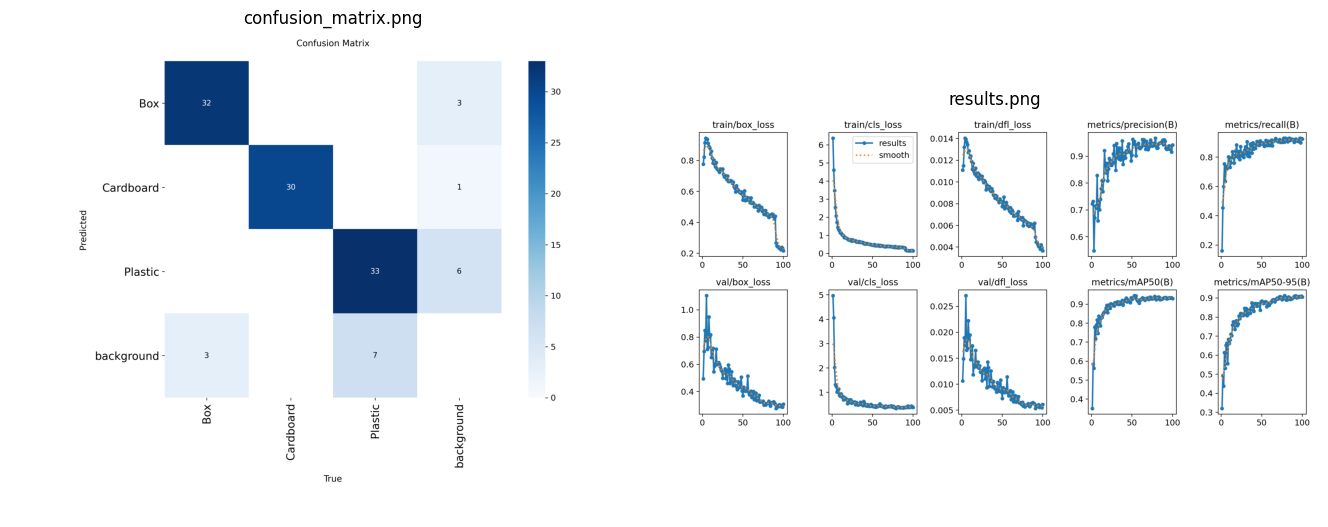

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

print(f"Mean Average Precision @.5: {results.results_dict['metrics/mAP50(B)']:.4f}")
print(f"Mean Average Precision @.5:.95: {results.results_dict['metrics/mAP50-95(B)']:.4f}")

run_dir = results.save_dir
plots = ['confusion_matrix.png', 'results.png', 'F1_curve.png']

plt.figure(figsize=(20, 10))
for i, plot_name in enumerate(plots):
    path = os.path.join(run_dir, plot_name)
    if os.path.exists(path):
        plt.subplot(1, 3, i+1)
        img = mpimg.imread(path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(plot_name)

plt.tight_layout()
plt.show()

In [ ]:
metrics = model.val()
print(f"mAP50-95: {metrics.box.map:.3f}")
print(f"mAP50: {metrics.box.map50:.3f}")
print(f"mAP75: {metrics.box.map75:.3f}")

Ultralytics 8.4.57 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 580.6±166.6 MB/s, size: 25.3 KB)
val: Scanning /content/bottle-3/valid/labels.cache... 105 images, 9 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 105/105 18.4Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 99, len(boxes) = 105. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.5it/s 4.6s
                   all        105        105      0.947      0.905       0.94      0.913
                   Box         35         35      0.912      0.914      0.954      0.937
             Cardboard         30         30